# LiLT on FUNSD — End-to-End Reproduction, Ablations & Robustness Study

This notebook reproduces LiLT (ACL 2022) semantic entity recognition on FUNSD,
runs the required layout-ablation baselines, and runs an OCR/layout-corruption
robustness sweep

In [1]:
# !pip cache purge
# !pip install --upgrade pip setuptools wheel

In [2]:
# --- Cell 1: Mount Drive and install dependencies ---
# We mount Drive FIRST because everything downstream (encoded dataset,
# model checkpoints, metrics, logits) gets cached there. Without this,
# every notebook restart (Colab wipes local disk) would force a full retrain.

from google.colab import drive
drive.mount('/content/drive')

# -q keeps install output quiet; these are the exact packages the pipeline needs.
%pip install -q transformers datasets evaluate seqeval accelerate


Mounted at /content/drive
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [3]:
# --- Cell 2: Global config ---
# Single source of truth for every constant used below. Change values here,
# not inside individual cells.
import os

CHECKPOINT = "SCUT-DLVCLab/lilt-roberta-en-base"
TEXT_ONLY_CHECKPOINT = "roberta-base"

DATASET_ID = "nielsr/funsd-layoutlmv3"
TOKEN_COLUMN = "tokens"

CACHE_ROOT = "/content/drive/MyDrive/lilt_reproduction_cache"
os.makedirs(CACHE_ROOT, exist_ok=True)

SEEDS = [42, 123, 2024]
MAX_STEPS = 2500
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 5e-5
MAX_SEQ_LENGTH = 512

FORCE_RETRAIN = False

N_SEEDS_ABLATION = 1   # ablations test yes/no "does layout matter" -- bump if a result comes back close to lilt_true

CORRUPTION_FRACTIONS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
JITTER_MAGNITUDES     = [0, 10, 25, 50, 100]

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [4]:
# --- Cell 3: Load FUNSD and sanity-check the raw data ---
# This is the same structural check from your Week 1 work: word/box/label
# list lengths must agree per document, and boxes must already be on FUNSD's
# native 0-1000 normalized scale (which is what LiLT's tokenizer expects).

from datasets import load_dataset

dataset = load_dataset(DATASET_ID)
label_names = dataset["train"].features["ner_tags"].feature.names
id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

print(dataset)
print("\nLabels:", label_names)
print("Train docs:", len(dataset["train"]), " Test docs:", len(dataset["test"]))

example = dataset["train"][0]
assert len(example[TOKEN_COLUMN]) == len(example["bboxes"]) == len(example["ner_tags"])
assert all(len(b) == 4 for b in example["bboxes"])
assert all(0 <= c <= 1000 for b in example["bboxes"] for c in b)
print("\n[OK] tokens / boxes / labels are aligned and boxes are in the 0-1000 range.")
print("NOTE: this dataset carries segment-level boxes -- every word in a line shares")
print("one bounding box, unlike nielsr/funsd's per-word boxes. That's the change that")
print("closed the gap to the paper's 0.8841 F1.")

README.md:   0%|          | 0.00/770 [00:00<?, ?B/s]

funsd/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 26.3MB            

funsd/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

funsd/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 9.54MB            

funsd/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image'],
        num_rows: 149
    })
    test: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image'],
        num_rows: 50
    })
})

Labels: ['O', 'B-HEADER', 'I-HEADER', 'B-QUESTION', 'I-QUESTION', 'B-ANSWER', 'I-ANSWER']
Train docs: 149  Test docs: 50

[OK] tokens / boxes / labels are aligned and boxes are in the 0-1000 range.
NOTE: this dataset carries segment-level boxes -- every word in a line shares
one bounding box, unlike nielsr/funsd's per-word boxes. That's the change that
closed the gap to the paper's 0.8841 F1.


In [5]:
# --- Cell 4: Tokenizer + encoding function ---
#
# IMPORTANT DIFFERENCE FROM YOUR ORIGINAL NOTEBOOK:
# This checkpoint's tokenizer_config.json declares tokenizer_class =
# LayoutLMv3Tokenizer, which has a `word_labels=` argument that does the
# subword-label-alignment (first-subword-only, -100 for the rest, -100 for
# specials/padding) for you internally, using the SAME convention as the
# official HF LiLT tutorial your Week-1 notebook cites as a reference point
# (~0.89 F1 from 149 examples). Your original notebook re-implemented this
# alignment by hand via word_ids(). That's not necessarily wrong, but it's
# an extra place a subtle bug can hide, and it's a plausible contributor to
# any gap between your numbers and the community reproductions that use the
# built-in word_labels= path. Worth comparing against your manual version
# if the gap doesn't close after checking Cell 15/16.

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
text_only_tokenizer = AutoTokenizer.from_pretrained(TEXT_ONLY_CHECKPOINT, add_prefix_space=True)

def encode_with_boxes(example):
    encoding = tokenizer(
        example[TOKEN_COLUMN],
        boxes=example["bboxes"],
        word_labels=example["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=MAX_SEQ_LENGTH,
    )
    return encoding

def encode_text_only(example):
    """No box information -- plain RoBERTa. Text content is identical to the
    segment-box version (only 'tokens'/'bboxes' representation differs), so
    this baseline is unaffected by the dataset switch."""
    encoding = text_only_tokenizer(
        example[TOKEN_COLUMN],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=MAX_SEQ_LENGTH,
    )
    word_ids = encoding.word_ids()
    labels, prev = [], None
    for wid in word_ids:
        if wid is None:
            labels.append(-100)
        elif wid != prev:
            labels.append(example["ner_tags"][wid])
        else:
            labels.append(-100)
        prev = wid
    encoding["labels"] = labels
    return encoding

config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [6]:
# --- Cell 5: Encode + cache the dataset (Drive-backed) ---
# Tokenizing FUNSD is fast, but we still cache it: it keeps every downstream
# cell's inputs byte-identical across runtime restarts, and it means the
# ablation variants below (zero-box, shuffled-box) all derive from exactly
# this one cached encoding rather than being re-tokenized separately.

from datasets import load_from_disk

def get_or_build_encoded_dataset(cache_name, encode_fn, remove_columns, source_dataset=None):
    if source_dataset is None:
        source_dataset = dataset
    cache_path = os.path.join(CACHE_ROOT, "encoded", cache_name)
    if os.path.exists(cache_path) and not FORCE_RETRAIN:
        print(f"[cache hit] loading encoded dataset '{cache_name}' from Drive")
        return load_from_disk(cache_path)
    print(f"[cache miss] encoding dataset '{cache_name}' ...")
    encoded = source_dataset.map(encode_fn, remove_columns=remove_columns)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    encoded.save_to_disk(cache_path)
    return encoded

RAW_COLUMNS = dataset["train"].column_names   # includes 'image' now -- dropped automatically here

# NOTE: cache names prefixed "segment_" -- distinct from your original
# "true_boxes"/"text_only" caches, which still exist on Drive from the
# per-word run and are left untouched.
encoded_true = get_or_build_encoded_dataset("segment_true_boxes", encode_with_boxes, RAW_COLUMNS)
encoded_text_only = get_or_build_encoded_dataset("segment_text_only", encode_text_only, RAW_COLUMNS)

print(encoded_true)
print(encoded_text_only)


[cache hit] loading encoded dataset 'segment_true_boxes' from Drive
[cache hit] loading encoded dataset 'segment_text_only' from Drive
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'bbox', 'labels'],
        num_rows: 149
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'bbox', 'labels'],
        num_rows: 50
    })
})
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 149
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 50
    })
})


In [7]:
# --- Cell 6: Metrics ---
# Entity-level precision/recall/F1 via seqeval -- matches the paper's metric.
# We also keep a full per-class report function for diagnostics (Cell 16),
# since the aggregate F1 alone hides exactly the kind of per-class story
# that matters for honest reporting.

import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

def _decode(predictions, label_ids):
    """Turn raw logits + label ids into seqeval-ready label-name sequences,
    dropping every position marked -100 (subwords / specials / padding)."""
    preds = np.argmax(predictions, axis=-1)
    true_seqs, pred_seqs = [], []
    for pred_row, true_row in zip(preds, label_ids):
        t_seq, p_seq = [], []
        for p, t in zip(pred_row, true_row):
            if t == -100:
                continue
            t_seq.append(label_names[t])
            p_seq.append(label_names[p])
        true_seqs.append(t_seq)
        pred_seqs.append(p_seq)
    return true_seqs, pred_seqs

def compute_metrics(eval_pred):
    logits, label_ids = eval_pred
    true_seqs, pred_seqs = _decode(logits, label_ids)
    return {
        "precision": precision_score(true_seqs, pred_seqs),
        "recall": recall_score(true_seqs, pred_seqs),
        "f1": f1_score(true_seqs, pred_seqs),
    }

def full_report(logits, label_ids):
    """Per-class precision/recall/F1/support -- use this whenever a number
    looks surprising, before writing any explanation into a report."""
    true_seqs, pred_seqs = _decode(logits, label_ids)
    return classification_report(true_seqs, pred_seqs, digits=4)


In [8]:
# --- Cell 7: Collators (one per input schema) ---
# LiLT-based runs need a 'bbox' tensor; the text-only RoBERTa run doesn't
# have one at all, so it needs its own collator or Trainer will choke on a
# missing key.

import torch as _torch

def collate_with_bbox(features):
    return {
        "input_ids": _torch.tensor([f["input_ids"] for f in features], dtype=_torch.long),
        "attention_mask": _torch.tensor([f["attention_mask"] for f in features], dtype=_torch.long),
        "bbox": _torch.tensor([f["bbox"] for f in features], dtype=_torch.long),
        "labels": _torch.tensor([f["labels"] for f in features], dtype=_torch.long),
    }

def collate_text_only(features):
    return {
        "input_ids": _torch.tensor([f["input_ids"] for f in features], dtype=_torch.long),
        "attention_mask": _torch.tensor([f["attention_mask"] for f in features], dtype=_torch.long),
        "labels": _torch.tensor([f["labels"] for f in features], dtype=_torch.long),
    }


In [9]:
# --- Cell 8: The cache-or-train harness ---
# Every experiment (a run_name + seed pair) gets its own folder under
# CACHE_ROOT/runs/ on Drive -- but only metrics.json, logits.npy, and
# label_ids.npy live there (a few MB total). Full model weights are only
# written to Drive when keep_model_on_drive=True is explicitly passed, and
# even then via trainer.save_model() at the end, never via Trainer's own
# step-based checkpointing -- that now points at local Colab disk, since
# nothing downstream ever reads those intermediate checkpoints back.

import json
from transformers import TrainingArguments, Trainer, set_seed

LOCAL_SCRATCH = "/content/local_runs"
os.makedirs(LOCAL_SCRATCH, exist_ok=True)

def build_training_args(local_output_dir, seed, max_steps=MAX_STEPS):
    warmup_steps = int(0.1 * max_steps)
    return TrainingArguments(
        output_dir=local_output_dir,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,   # now 1, matches reference config
        max_steps=max_steps,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="linear",
        warmup_steps=warmup_steps,
        weight_decay=0.01,
        fp16=(DEVICE == "cuda"),
        save_strategy="steps",
        save_steps=250,
        eval_strategy="steps",
        eval_steps=250,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        seed=seed,
        report_to="none",
    )

def train_or_load(run_name, seed, model_init_fn, train_ds, eval_ds, collate_fn,
                   max_steps=MAX_STEPS, keep_model_on_drive=False):
    run_dir = os.path.join(CACHE_ROOT, "runs", run_name, f"seed_{seed}")
    local_dir = os.path.join(LOCAL_SCRATCH, run_name, f"seed_{seed}")
    metrics_path = os.path.join(run_dir, "metrics.json")

    if os.path.exists(metrics_path) and not FORCE_RETRAIN:
        print(f"[cache hit] {run_name} / seed {seed} -- loading saved results, no training")
        metrics = json.load(open(metrics_path))
        logits = np.load(os.path.join(run_dir, "logits.npy"))
        label_ids = np.load(os.path.join(run_dir, "label_ids.npy"))
        return metrics, logits, label_ids

    print(f"[cache miss] {run_name} / seed {seed} -- training now")
    os.makedirs(run_dir, exist_ok=True)
    os.makedirs(local_dir, exist_ok=True)
    set_seed(seed)
    model = model_init_fn()
    args = build_training_args(local_dir, seed, max_steps)
    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=eval_ds,
        data_collator=collate_fn, compute_metrics=compute_metrics,
    )
    trainer.train()
    metrics = trainer.evaluate()
    pred_out = trainer.predict(eval_ds)

    np.save(os.path.join(run_dir, "logits.npy"), pred_out.predictions)
    np.save(os.path.join(run_dir, "label_ids.npy"), pred_out.label_ids)
    json.dump(metrics, open(metrics_path, "w"), indent=2)

    if keep_model_on_drive:
        trainer.save_model(os.path.join(run_dir, "model"))

    return metrics, pred_out.predictions, pred_out.label_ids

In [10]:
# --- Cell 9: Build the layout-ablation dataset variants ---
# These three all reuse the SAME tokenized 'encoded_true' dataset (same
# input_ids, same labels) and only change the 'bbox' column. That isolation
# is what makes the ablation a fair test of layout information specifically,
# rather than a test of a different tokenization pipeline.

def zero_out_boxes(example):
    example = dict(example)
    example["bbox"] = [[0, 0, 0, 0] for _ in example["bbox"]]
    return example

def shuffle_boxes(example, seed=0):
    example = dict(example)
    boxes = list(example["bbox"])
    attn = example["attention_mask"]
    real_idx = [i for i, a in enumerate(attn) if a == 1]
    rng = np.random.RandomState(seed)
    shuffled_order = real_idx.copy()
    rng.shuffle(shuffled_order)
    new_boxes = list(boxes)
    for src, dst in zip(real_idx, shuffled_order):
        new_boxes[dst] = boxes[src]
    example["bbox"] = new_boxes
    return example

zero_box_cache = os.path.join(CACHE_ROOT, "encoded", "segment_zero_boxes")
if os.path.exists(zero_box_cache) and not FORCE_RETRAIN:
    encoded_zero = load_from_disk(zero_box_cache)
else:
    encoded_zero = encoded_true.map(zero_out_boxes)
    encoded_zero.save_to_disk(zero_box_cache)

shuffled_box_cache = os.path.join(CACHE_ROOT, "encoded", "segment_shuffled_boxes")
if os.path.exists(shuffled_box_cache) and not FORCE_RETRAIN:
    encoded_shuffled = load_from_disk(shuffled_box_cache)
else:
    encoded_shuffled = encoded_true.map(lambda ex: shuffle_boxes(ex, seed=0))
    encoded_shuffled.save_to_disk(shuffled_box_cache)

print("Ablation datasets ready:", encoded_zero, encoded_shuffled)

Ablation datasets ready: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'bbox', 'labels'],
        num_rows: 149
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'bbox', 'labels'],
        num_rows: 50
    })
}) DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'bbox', 'labels'],
        num_rows: 149
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'bbox', 'labels'],
        num_rows: 50
    })
})


In [11]:
# --- Cell 10: Model init functions ---
# Kept as small factory functions (not module-level model objects) so
# train_or_load can build a FRESH model per seed -- reusing one model
# instance across seeds would leak weights between runs.

from transformers import LiltForTokenClassification, RobertaForTokenClassification

def init_lilt():
    return LiltForTokenClassification.from_pretrained(
        CHECKPOINT, num_labels=len(label_names), id2label=id2label, label2id=label2id,
    )

def init_roberta_text_only():
    return RobertaForTokenClassification.from_pretrained(
        TEXT_ONLY_CHECKPOINT, num_labels=len(label_names), id2label=id2label, label2id=label2id,
    )


In [12]:
# --- Cell 11: Core reproduction -- LiLT + true boxes, 3 seeds ---
# This is your Week 2 result. Re-running this cell after the first time
# will hit the cache for all 3 seeds and finish in a few seconds.

lilt_true_results = {}
for seed in SEEDS:
    metrics, logits, label_ids = train_or_load(
        "lilt_true_segment", seed, init_lilt, encoded_true["train"], encoded_true["test"], collate_with_bbox,
        keep_model_on_drive=(seed == 42),
    )
    lilt_true_results[seed] = {"metrics": metrics, "logits": logits, "label_ids": label_ids}
    print(f"seed {seed}: F1={metrics['eval_f1']:.4f}  P={metrics['eval_precision']:.4f}  R={metrics['eval_recall']:.4f}")

[cache hit] lilt_true_segment / seed 42 -- loading saved results, no training
seed 42: F1=0.8783  P=0.8664  R=0.8905
[cache hit] lilt_true_segment / seed 123 -- loading saved results, no training
seed 123: F1=0.8830  P=0.8731  R=0.8931
[cache hit] lilt_true_segment / seed 2024 -- loading saved results, no training
seed 2024: F1=0.8861  P=0.8697  R=0.9032


In [13]:
# --- Cell 12: Required baselines ---
# text-only RoBERTa, LiLT+zero-boxes, LiLT+shuffled-boxes -- same 3 seeds,
# same training budget, so the ONLY thing that differs between a row here
# and Cell 11 is the layout information available to the model.

baseline_results = {"roberta_text_only": {}, "lilt_zero": {}, "lilt_shuffled": {}}
ablation_seeds = SEEDS[:N_SEEDS_ABLATION]

for seed in ablation_seeds:
    m, lg, li = train_or_load("roberta_text_only_segment", seed, init_roberta_text_only,
                               encoded_text_only["train"], encoded_text_only["test"], collate_text_only)
    baseline_results["roberta_text_only"][seed] = {"metrics": m, "logits": lg, "label_ids": li}

for seed in ablation_seeds:
    m, lg, li = train_or_load("lilt_zero_segment", seed, init_lilt,
                               encoded_zero["train"], encoded_zero["test"], collate_with_bbox)
    baseline_results["lilt_zero"][seed] = {"metrics": m, "logits": lg, "label_ids": li}

for seed in ablation_seeds:
    m, lg, li = train_or_load("lilt_shuffled_segment", seed, init_lilt,
                               encoded_shuffled["train"], encoded_shuffled["test"], collate_with_bbox)
    baseline_results["lilt_shuffled"][seed] = {"metrics": m, "logits": lg, "label_ids": li}

for name, per_seed in baseline_results.items():
    f1s = [v["metrics"]["eval_f1"] for v in per_seed.values()]
    print(f"{name:20s}  mean F1 = {np.mean(f1s):.4f}  std = {np.std(f1s) if len(f1s)>1 else 0:.4f}")

[cache hit] roberta_text_only_segment / seed 42 -- loading saved results, no training
[cache hit] lilt_zero_segment / seed 42 -- loading saved results, no training
[cache hit] lilt_shuffled_segment / seed 42 -- loading saved results, no training
roberta_text_only     mean F1 = 0.7235  std = 0.0000
lilt_zero             mean F1 = 0.7185  std = 0.0000
lilt_shuffled         mean F1 = 0.7203  std = 0.0000


In [14]:
# --- Cell 13: Results table (reproduction + all baselines) ---
# One table, saved to Drive as CSV so it can go straight into a report
# without re-deriving it from the raw run folders.

import pandas as pd

def summarize(name, per_seed):
    f1s = [v["metrics"]["eval_f1"] for v in per_seed.values()]
    ps  = [v["metrics"]["eval_precision"] for v in per_seed.values()]
    rs  = [v["metrics"]["eval_recall"] for v in per_seed.values()]
    return {
        "condition": name,
        "mean_f1": np.mean(f1s), "std_f1": np.std(f1s),
        "mean_precision": np.mean(ps), "mean_recall": np.mean(rs),
        "n_seeds": len(f1s),
    }

rows = [summarize("lilt_true_boxes", lilt_true_results)]
rows += [summarize(name, per_seed) for name, per_seed in baseline_results.items()]
results_df = pd.DataFrame(rows)
results_df["paper_f1_reference"] = 0.8841   # LiLT[EN-RoBERTa]base, Table 2 of the paper -- for context only, not a row to average in

display(results_df)
results_df.to_csv(os.path.join(CACHE_ROOT, "results_table.csv"), index=False)
print(f"Saved to {CACHE_ROOT}/results_table.csv")


,condition,mean_f1,std_f1,mean_precision,mean_recall,n_seeds,paper_f1_reference
0,lilt_true_boxes,0.882464,0.003224,0.869735,0.895590,3,0.8841
1,roberta_text_only,0.723549,0.000000,0.697041,0.752154,1,0.8841
2,lilt_zero,0.718480,0.000000,0.700000,0.737962,1,0.8841
3,lilt_shuffled,0.720254,0.000000,0.695283,0.747086,1,0.8841


Saved to /content/drive/MyDrive/lilt_reproduction_cache/results_table.csv


In [15]:
# --- Cell 14: Corruption robustness helpers ---
# All of these operate on an ALREADY-ENCODED, ALREADY-PADDED example (a dict
# with input_ids / attention_mask / bbox / labels), and only ever touch
# "real content" positions (attention_mask==1). They're evaluation-time
# transforms -- no retraining involved, which is exactly why this extension
# is cheap.

def _real_positions(example):
    return [i for i, a in enumerate(example["attention_mask"]) if a == 1]

def corrupt_jitter(example, magnitude, seed=0):
    example = dict(example)
    boxes = [list(b) for b in example["bbox"]]
    rng = np.random.RandomState(seed)
    for i in _real_positions(example):
        noise = rng.randint(-magnitude, magnitude + 1, size=4) if magnitude > 0 else [0, 0, 0, 0]
        x0, y0, x1, y1 = [int(np.clip(c + n, 0, 1000)) for c, n in zip(boxes[i], noise)]
        # keep box well-formed (x0<=x1, y0<=y1) after jitter
        x0, x1 = sorted([x0, x1]); y0, y1 = sorted([y0, y1])
        boxes[i] = [x0, y0, x1, y1]
    example["bbox"] = boxes
    return example

def corrupt_dropout(example, fraction, seed=0):
    example = dict(example)
    boxes = [list(b) for b in example["bbox"]]
    real = _real_positions(example)
    rng = np.random.RandomState(seed)
    n_drop = int(round(fraction * len(real)))
    drop_idx = rng.choice(real, size=n_drop, replace=False) if n_drop > 0 else []
    for i in drop_idx:
        boxes[i] = [0, 0, 0, 0]
    example["bbox"] = boxes
    return example

def corrupt_shuffle(example, fraction, seed=0):
    """Shuffle boxes among a random FRACTION of real positions (fraction=1.0
    reproduces the full training-time shuffled-box condition, but here it's
    applied to the model trained on TRUE boxes, at eval time only)."""
    example = dict(example)
    boxes = [list(b) for b in example["bbox"]]
    real = _real_positions(example)
    rng = np.random.RandomState(seed)
    n_shuf = int(round(fraction * len(real)))
    chosen = list(rng.choice(real, size=n_shuf, replace=False)) if n_shuf > 0 else []
    shuffled = chosen.copy()
    rng.shuffle(shuffled)
    orig = {i: boxes[i] for i in chosen}
    for src, dst in zip(chosen, shuffled):
        boxes[dst] = orig[src]
    example["bbox"] = boxes
    return example

def corrupt_mismatch(example, fraction, seed=0):
    """Swap box<->token pairing for a fraction of positions, in disjoint
    pairs -- a more localized corruption than a full shuffle."""
    example = dict(example)
    boxes = [list(b) for b in example["bbox"]]
    real = _real_positions(example)
    rng = np.random.RandomState(seed)
    n_pairs = int(round(fraction * len(real) / 2))
    n_pairs = min(n_pairs, len(real) // 2)   # can't form more pairs than the pool allows
    pool = real.copy(); rng.shuffle(pool)
    for k in range(n_pairs):
        a, b = pool[2 * k], pool[2 * k + 1]
        boxes[a], boxes[b] = boxes[b], boxes[a]
    example["bbox"] = boxes
    return example


In [23]:
# --- Cell 15: Corruption robustness sweep, with error bars across corruption seeds ---
from transformers import Trainer, TrainingArguments

SWEEP_MODEL = "lilt_true_segment"   # the model actually being reported

def load_trained_lilt(run_name, seed):
    model_dir = os.path.join(CACHE_ROOT, "runs", run_name, f"seed_{seed}", "model")
    assert os.path.isdir(model_dir), f"No saved model at {model_dir}. Cell 11 must finish seed 42 first."
    return LiltForTokenClassification.from_pretrained(model_dir)

def evaluate_corruption_seeded(name, fn, severity, base_dataset, model, seed):
    cache_dir = os.path.join(CACHE_ROOT, "corruption_segment_seeds", name, f"severity_{severity}", f"seed_{seed}")
    mp = os.path.join(cache_dir, "metrics.json")
    if os.path.exists(mp) and not FORCE_RETRAIN:
        return json.load(open(mp))["eval_f1"]
    corrupted = base_dataset.map(lambda ex: fn(ex, severity, seed=seed))
    args = TrainingArguments(output_dir="/tmp/corruption_eval", per_device_eval_batch_size=8, report_to="none")
    trainer = Trainer(model=model, args=args, data_collator=collate_with_bbox, compute_metrics=compute_metrics)
    metrics = trainer.evaluate(eval_dataset=corrupted)
    os.makedirs(cache_dir, exist_ok=True)
    json.dump(metrics, open(mp, "w"), indent=2)
    return metrics["eval_f1"]

trained_model = load_trained_lilt(SWEEP_MODEL, seed=42)

sweeps = {
    "jitter":   (corrupt_jitter,   JITTER_MAGNITUDES),
    "dropout":  (corrupt_dropout,  CORRUPTION_FRACTIONS),
    "shuffle":  (corrupt_shuffle,  CORRUPTION_FRACTIONS),
    "mismatch": (corrupt_mismatch, CORRUPTION_FRACTIONS),
}

sweep_stats = {}
for name, (fn, levels) in sweeps.items():
    sweep_stats[name] = {}
    for lvl in levels:
        f1s = [evaluate_corruption_seeded(name, fn, lvl, encoded_true["test"], trained_model, s) for s in CORRUPTION_SEEDS]
        sweep_stats[name][lvl] = (float(np.mean(f1s)), float(np.std(f1s, ddof=1)))
    print(name, {k: f"{m:.3f}±{s:.3f}" for k, (m, s) in sweep_stats[name].items()})

# Guard: severity-0, seed-42 point must match this model's own eval F1.
f1_clean = json.load(open(os.path.join(
    CACHE_ROOT, "corruption_segment_seeds", "dropout", "severity_0.0", "seed_42", "metrics.json")))["eval_f1"]
ref = lilt_true_results[42]["metrics"]["eval_f1"]
print(f"clean-point F1 {f1_clean:.4f} vs seed-42 eval F1 {ref:.4f}")
assert abs(f1_clean - ref) < 0.005, "Sweep is not running on the model you are reporting"

Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

jitter {0: '0.878±0.000', 10: '0.852±0.004', 25: '0.756±0.015', 50: '0.603±0.016', 100: '0.497±0.012'}
dropout {0.0: '0.878±0.000', 0.1: '0.856±0.002', 0.25: '0.824±0.004', 0.5: '0.700±0.012', 0.75: '0.493±0.011', 1.0: '0.154±0.000'}
shuffle {0.0: '0.878±0.000', 0.1: '0.805±0.005', 0.25: '0.698±0.014', 0.5: '0.461±0.007', 0.75: '0.321±0.007', 1.0: '0.276±0.002'}
mismatch {0.0: '0.878±0.000', 0.1: '0.804±0.002', 0.25: '0.689±0.008', 0.5: '0.458±0.009', 0.75: '0.320±0.007', 1.0: '0.271±0.010'}
clean-point F1 0.8785 vs seed-42 eval F1 0.8783


Saved plot to /content/drive/MyDrive/lilt_reproduction_cache/corruption_robustness_segment.png


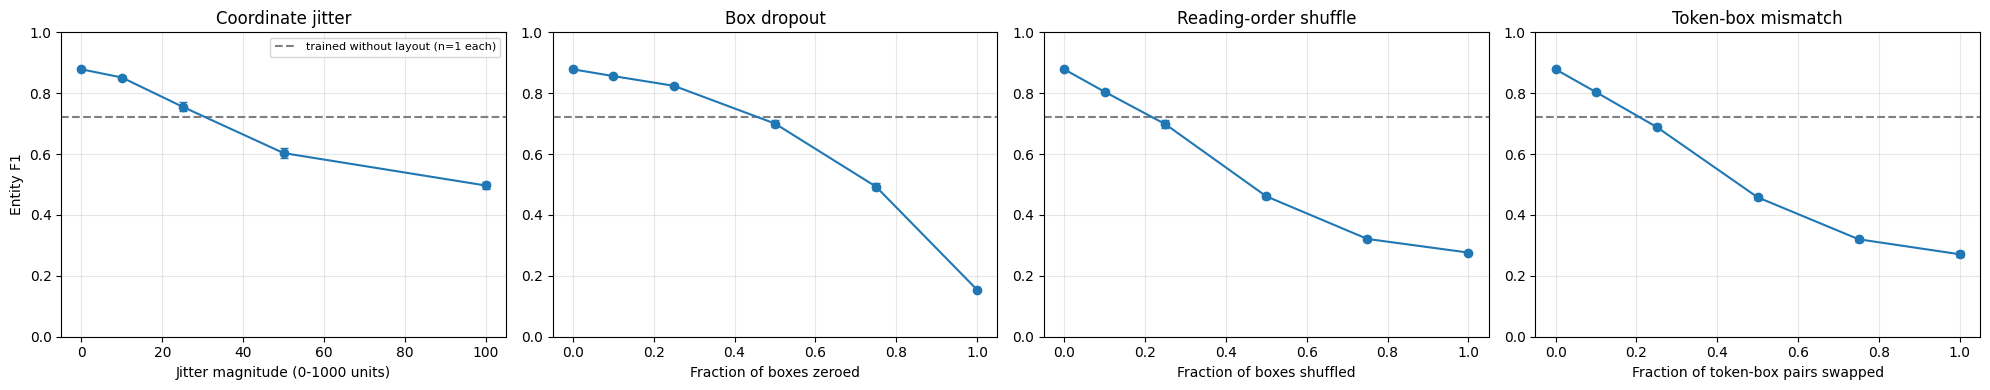

In [24]:
# --- Cell 16: Plot corruption robustness curves with error bars ---
import matplotlib.pyplot as plt

# Layout-free reference line: mean of the three n=1 baselines (text-only, zero-box, shuffled-box).
ref_no_layout = np.mean([v["metrics"]["eval_f1"] for d in baseline_results.values() for v in d.values()])

titles = {"jitter": "Coordinate jitter", "dropout": "Box dropout",
          "shuffle": "Reading-order shuffle", "mismatch": "Token-box mismatch"}
xlabels = {"jitter": "Jitter magnitude (0-1000 units)", "dropout": "Fraction of boxes zeroed",
           "shuffle": "Fraction of boxes shuffled", "mismatch": "Fraction of token-box pairs swapped"}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, stats) in zip(axes, sweep_stats.items()):
    xs = list(stats.keys())
    means = [stats[x][0] for x in xs]
    stds = [stats[x][1] for x in xs]
    ax.errorbar(xs, means, yerr=stds, marker="o", capsize=3)
    ax.axhline(ref_no_layout, ls="--", color="gray", label="trained without layout (n=1 each)")
    ax.set_title(titles[name]); ax.set_xlabel(xlabels[name])
    ax.set_ylim(0, 1); ax.grid(alpha=0.3)

axes[0].set_ylabel("Entity F1")
axes[0].legend(fontsize=8)
plt.tight_layout()
plot_path = os.path.join(CACHE_ROOT, "corruption_robustness_segment.png")
plt.savefig(plot_path, dpi=150)
print("Saved plot to", plot_path)
plt.show()

In [25]:
# --- Cell 17: Diagnostics -- truncation check + per-class error report ---
def count_tokens_before_truncation(example):
    enc = tokenizer(example[TOKEN_COLUMN], boxes=example["bboxes"], truncation=False)
    return {"n_tokens": len(enc["input_ids"])}

test_light = dataset["test"].select_columns([TOKEN_COLUMN, "bboxes"])
token_counts = test_light.map(count_tokens_before_truncation)["n_tokens"]
n_over = sum(1 for t in token_counts if t > MAX_SEQ_LENGTH)
print(f"Test documents exceeding {MAX_SEQ_LENGTH} tokens before truncation: {n_over} / {len(token_counts)}")
print(f"Max token count in test set: {max(token_counts)}")

seed42 = lilt_true_results[42]
print("\n--- Per-class report: LiLT segment-box, seed 42 ---")
print(full_report(seed42["logits"], seed42["label_ids"]))

Test documents exceeding 512 tokens before truncation: 4 / 50
Max token count in test set: 954

--- Per-class report: LiLT segment-box, seed 42 ---
              precision    recall  f1-score   support

      ANSWER     0.8651    0.9081    0.8861       805
      HEADER     0.5865    0.5126    0.5471       119
    QUESTION     0.8943    0.9199    0.9070      1049

   micro avg     0.8664    0.8905    0.8783      1973
   macro avg     0.7820    0.7802    0.7800      1973
weighted avg     0.8638    0.8905    0.8767      1973

